In [1]:
# Install required libraries
!pip install tensorflow opencv-python scikit-image -q

# Imports
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from PIL import Image, ImageDraw
import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries ready!')
print(f'TensorFlow version: {keras.__version__}')

✅ All libraries ready!
TensorFlow version: 3.13.2


PART 1: ADVANCED PREPROCESSING


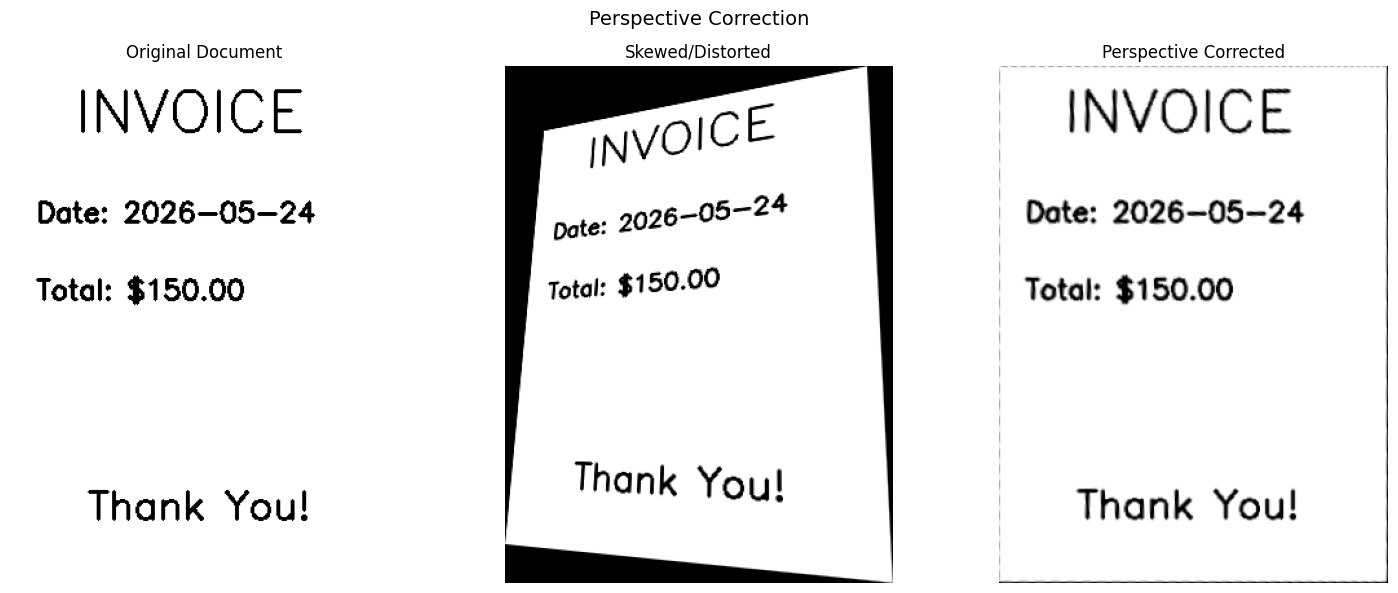

✅ Perspective correction complete!


In [2]:
# Part 1: Advanced Preprocessing
print("=" * 50)
print("PART 1: ADVANCED PREPROCESSING")
print("=" * 50)

def order_points(pts):
    rect = np.zeros((4, 2), dtype='float32')
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]   # Top-left
    rect[2] = pts[np.argmax(s)]   # Bottom-right
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)] # Top-right
    rect[3] = pts[np.argmax(diff)] # Bottom-left
    return rect

def four_point_transform(image, pts):
    rect = order_points(pts)
    (tl, tr, br, bl) = rect

    # Compute width
    widthA = np.linalg.norm(br - bl)
    widthB = np.linalg.norm(tr - tl)
    maxWidth = max(int(widthA), int(widthB))

    # Compute height
    heightA = np.linalg.norm(tr - br)
    heightB = np.linalg.norm(tl - bl)
    maxHeight = max(int(heightA), int(heightB))

    # Destination points
    dst = np.array([
        [0, 0],
        [maxWidth - 1, 0],
        [maxWidth - 1, maxHeight - 1],
        [0, maxHeight - 1]], dtype='float32')

    # Perspective transform
    M = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(image, M, (maxWidth, maxHeight))
    return warped

# Create a test image with perspective distortion
def create_skewed_document():
    # Create base document
    doc = np.ones((400, 300, 3), dtype=np.uint8) * 255
    cv2.putText(doc, 'INVOICE', (50, 50),
                cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0,0,0), 2)
    cv2.putText(doc, 'Date: 2026-05-24', (20, 120),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,0), 2)
    cv2.putText(doc, 'Total: $150.00', (20, 180),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,0), 2)
    cv2.putText(doc, 'Thank You!', (60, 350),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,0), 2)

    # Apply perspective distortion
    h, w = doc.shape[:2]
    src_pts = np.float32([[0,0],[w,0],[w,h],[0,h]])
    dst_pts = np.float32([[30,50],[w-20,0],[w,h],[0,h-30]])
    M = cv2.getPerspectiveTransform(src_pts, dst_pts)
    skewed = cv2.warpPerspective(doc, M, (w, h))

    cv2.imwrite('skewed_doc.jpg', skewed)
    return doc, skewed

original, skewed = create_skewed_document()

# Apply correction
pts = np.float32([[30,50],[280,0],[300,400],[0,370]])
corrected = four_point_transform(skewed, pts)

# Display
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Document')
axes[1].imshow(cv2.cvtColor(skewed, cv2.COLOR_BGR2RGB))
axes[1].set_title('Skewed/Distorted')
axes[2].imshow(cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB))
axes[2].set_title('Perspective Corrected')
for ax in axes: ax.axis('off')
plt.suptitle('Perspective Correction', fontsize=14)
plt.tight_layout()
plt.show()
print('✅ Perspective correction complete!')

Detected skew angle: -15.00 degrees


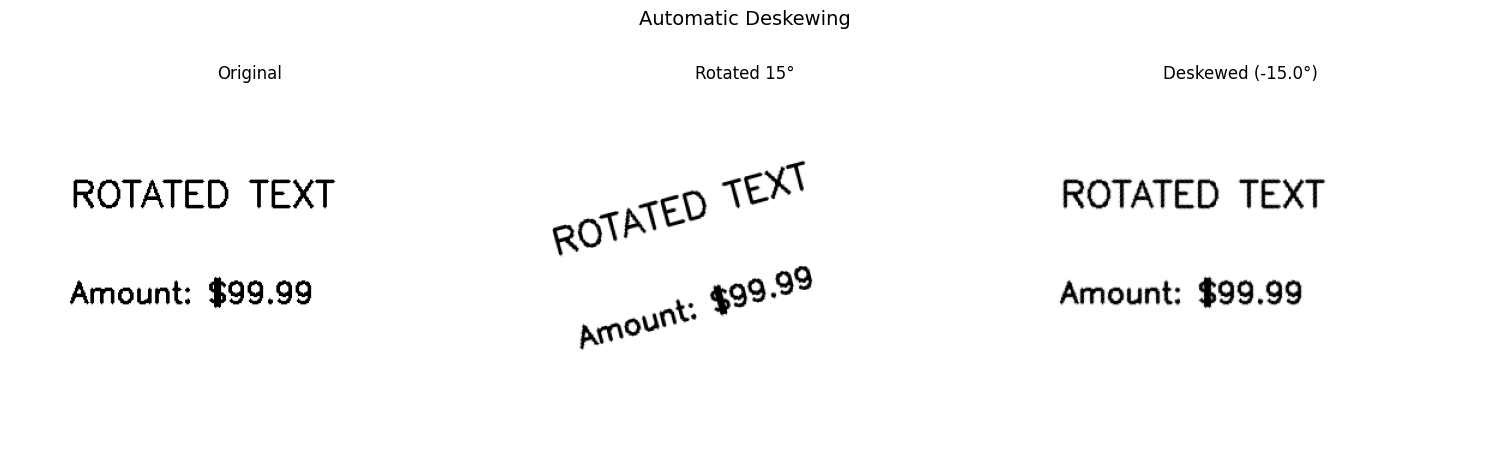

✅ Deskewing complete!


In [3]:
# Task 1.2: Automatic Deskewing
def deskew(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.bitwise_not(gray)
    thresh = cv2.threshold(gray, 0, 255,
                cv2.THRESH_BINARY | cv2.THRESH_OTSU)[1]
    coords = np.column_stack(np.where(thresh > 0))
    angle = cv2.minAreaRect(coords)[-1]
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, M, (w, h),
                flags=cv2.INTER_CUBIC,
                borderMode=cv2.BORDER_REPLICATE)
    return rotated, angle

# Create a rotated document
doc_test = np.ones((300, 400, 3), dtype=np.uint8) * 255
cv2.putText(doc_test, 'ROTATED TEXT', (50, 100),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,0), 2)
cv2.putText(doc_test, 'Amount: $99.99', (50, 180),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,0,0), 2)

# Rotate it by 15 degrees
h, w = doc_test.shape[:2]
M = cv2.getRotationMatrix2D((w//2, h//2), 15, 1.0)
rotated_doc = cv2.warpAffine(doc_test, M, (w, h),
                borderMode=cv2.BORDER_REPLICATE)

# Deskew it
deskewed, detected_angle = deskew(rotated_doc)
print(f'Detected skew angle: {detected_angle:.2f} degrees')

# Display
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(doc_test, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[1].imshow(cv2.cvtColor(rotated_doc, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Rotated 15°')
axes[2].imshow(cv2.cvtColor(deskewed, cv2.COLOR_BGR2RGB))
axes[2].set_title(f'Deskewed ({detected_angle:.1f}°)')
for ax in axes: ax.axis('off')
plt.suptitle('Automatic Deskewing', fontsize=14)
plt.tight_layout()
plt.show()
print('✅ Deskewing complete!')

MORPHOLOGICAL OPERATIONS


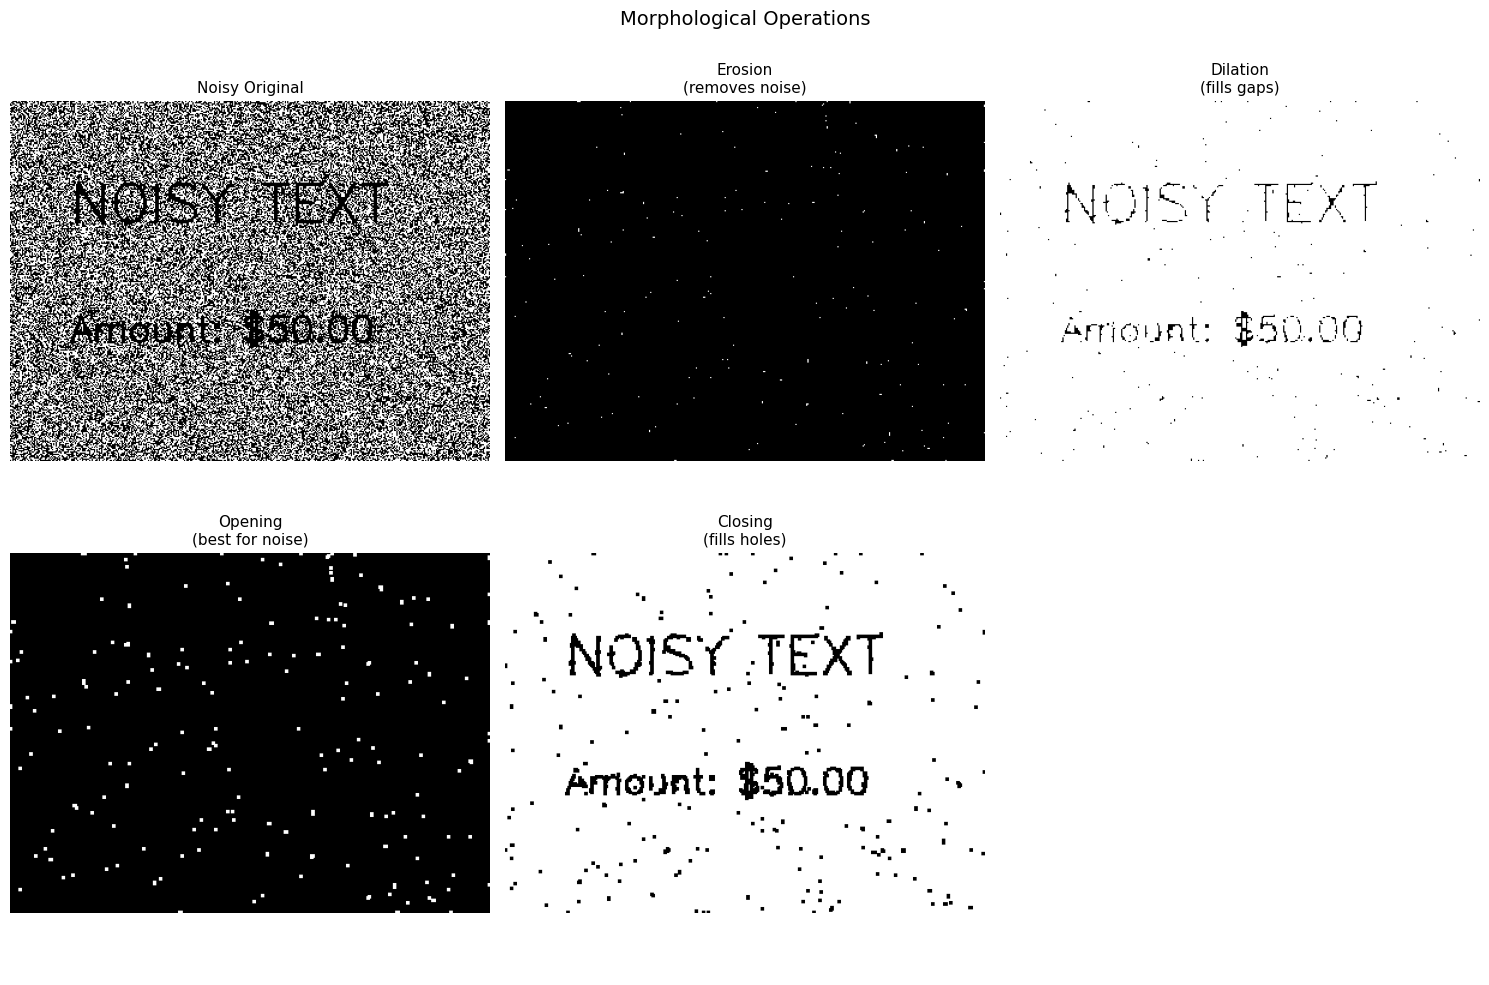

✅ Morphological operations complete!


In [4]:
# Task 1.3: Morphological Operations
print("=" * 50)
print("MORPHOLOGICAL OPERATIONS")
print("=" * 50)

# Create a noisy document
noisy = np.ones((300, 400), dtype=np.uint8) * 255
cv2.putText(noisy, 'NOISY TEXT', (50, 100),
            cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0,0,0), 2)
cv2.putText(noisy, 'Amount: $50.00', (50, 200),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,0), 2)

# Add random noise
noise = np.random.randint(0, 2, noisy.shape, dtype=np.uint8) * 255
noisy = cv2.bitwise_and(noisy, noise)

# Define kernel
kernel = np.ones((3, 3), np.uint8)

# Apply operations
erosion  = cv2.erode(noisy, kernel, iterations=1)
dilation = cv2.dilate(noisy, kernel, iterations=1)
opening  = cv2.morphologyEx(noisy, cv2.MORPH_OPEN, kernel)
closing  = cv2.morphologyEx(noisy, cv2.MORPH_CLOSE, kernel)

# Display
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
imgs = [noisy, erosion, dilation, opening, closing]
titles = ['Noisy Original', 'Erosion\n(removes noise)',
          'Dilation\n(fills gaps)', 'Opening\n(best for noise)',
          'Closing\n(fills holes)']

for idx, (ax, img, title) in enumerate(zip(axes.flat, imgs, titles)):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=11)
    ax.axis('off')

axes[1, 2].axis('off')  # hide last empty plot
plt.suptitle('Morphological Operations', fontsize=14)
plt.tight_layout()
plt.show()
print('✅ Morphological operations complete!')

PART 2: CNN FOR DIGIT RECOGNITION
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 60000
Test samples:     10000
Image shape:      (28, 28)
Labels range:     0 to 9


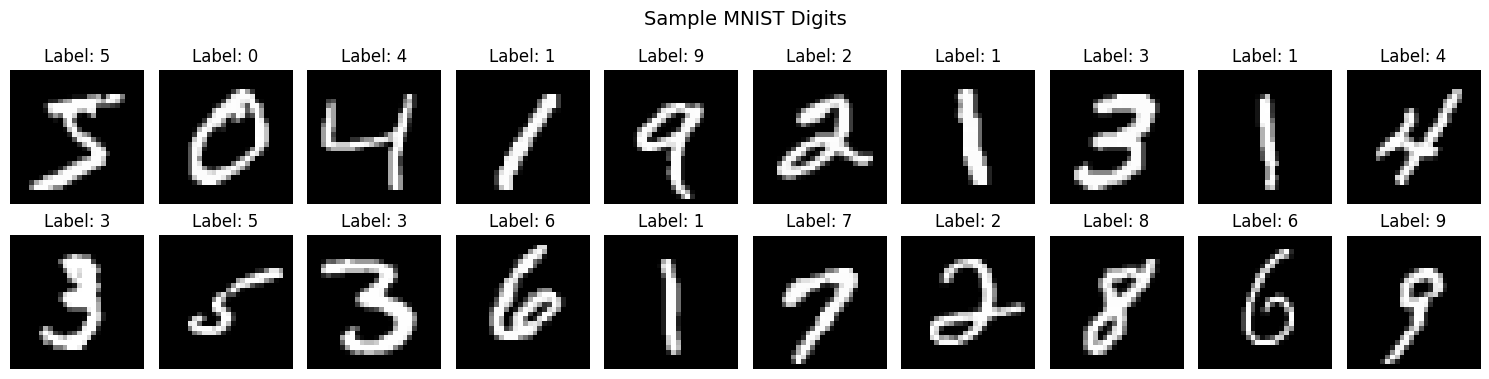

✅ MNIST dataset loaded!


In [5]:
# Part 2: Build CNN from Scratch
print("=" * 50)
print("PART 2: CNN FOR DIGIT RECOGNITION")
print("=" * 50)

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f'Training samples: {x_train.shape[0]}')
print(f'Test samples:     {x_test.shape[0]}')
print(f'Image shape:      {x_train.shape[1:]}')
print(f'Labels range:     {y_train.min()} to {y_train.max()}')

# Visualize sample digits
fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i in range(10):
    axes[0, i].imshow(x_train[i], cmap='gray')
    axes[0, i].set_title(f'Label: {y_train[i]}')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_train[i+10], cmap='gray')
    axes[1, i].set_title(f'Label: {y_train[i+10]}')
    axes[1, i].axis('off')

plt.suptitle('Sample MNIST Digits', fontsize=14)
plt.tight_layout()
plt.show()
print('✅ MNIST dataset loaded!')

In [6]:
# Preprocess data
x_train_cnn = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255
x_test_cnn  = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat  = keras.utils.to_categorical(y_test, 10)

print(f'Training data shape: {x_train_cnn.shape}')
print(f'Test data shape:     {x_test_cnn.shape}')

# Build CNN
model = keras.Sequential([
    # First convolutional block
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    # Second convolutional block
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Classifier
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Display architecture
model.summary()
print('✅ CNN architecture built!')

Training data shape: (60000, 28, 28, 1)
Test data shape:     (10000, 28, 28, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

✅ CNN architecture built!


In [7]:
# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
print('Training CNN... ⏳')
history = model.fit(
    x_train_cnn, y_train_cat,
    batch_size=128,
    epochs=10,
    validation_split=0.1,
    verbose=1
)

# Evaluate on test set
test_loss, test_acc = model.evaluate(x_test_cnn, y_test_cat, verbose=0)
print(f'\n🏆 Test Accuracy: {test_acc*100:.2f}%')
print(f'Target: 98%+ — {"✅ ACHIEVED!" if test_acc >= 0.98 else "Keep training!"}')

Training CNN... ⏳
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 92ms/step - accuracy: 0.9012 - loss: 0.3244 - val_accuracy: 0.9822 - val_loss: 0.0634
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 91ms/step - accuracy: 0.9701 - loss: 0.0997 - val_accuracy: 0.9877 - val_loss: 0.0449
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 39s 92ms/step - accuracy: 0.9780 - loss: 0.0727 - val_accuracy: 0.9867 - val_loss: 0.0441
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 90ms/step - accuracy: 0.9821 - loss: 0.0591 - val_accuracy: 0.9893 - val_loss: 0.0385
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 90ms/step - accuracy: 0.9850 - loss: 0.0502 - val_accuracy: 0.9913 - val_loss: 0.0358
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 91ms/step - accuracy: 0.9875 - loss: 0.0406 - val_accuracy: 0.9892 - val_loss: 0.0358
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 90ms/step - accuracy: 0.9890 - loss: 0.0372 - val_accuracy: 0.9915 - val_loss: 0.0314
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 90ms/step - accuracy: 0.9903

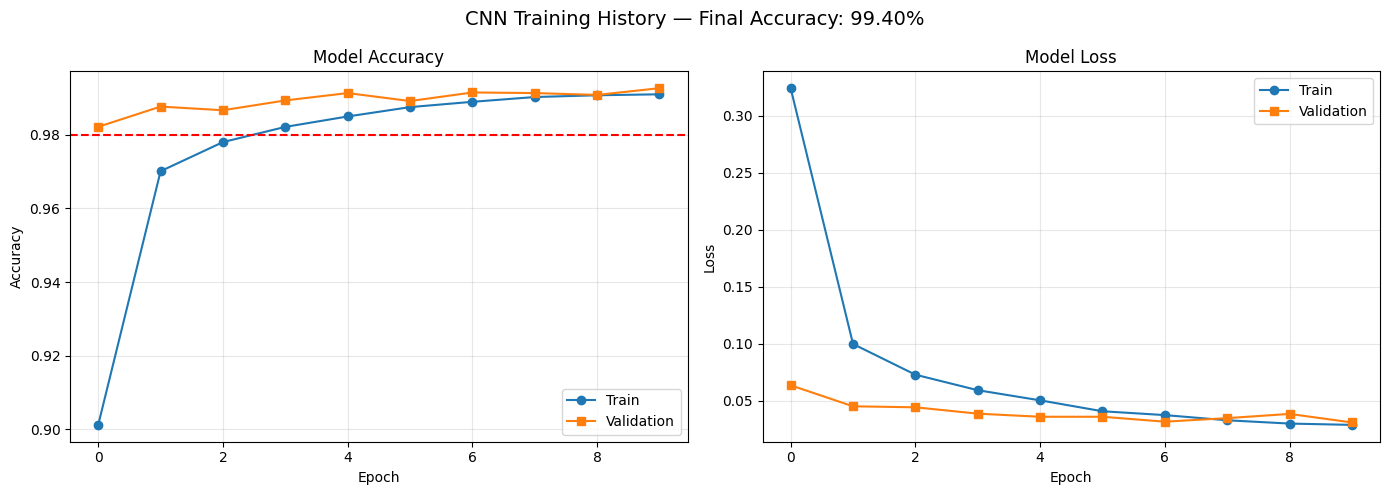

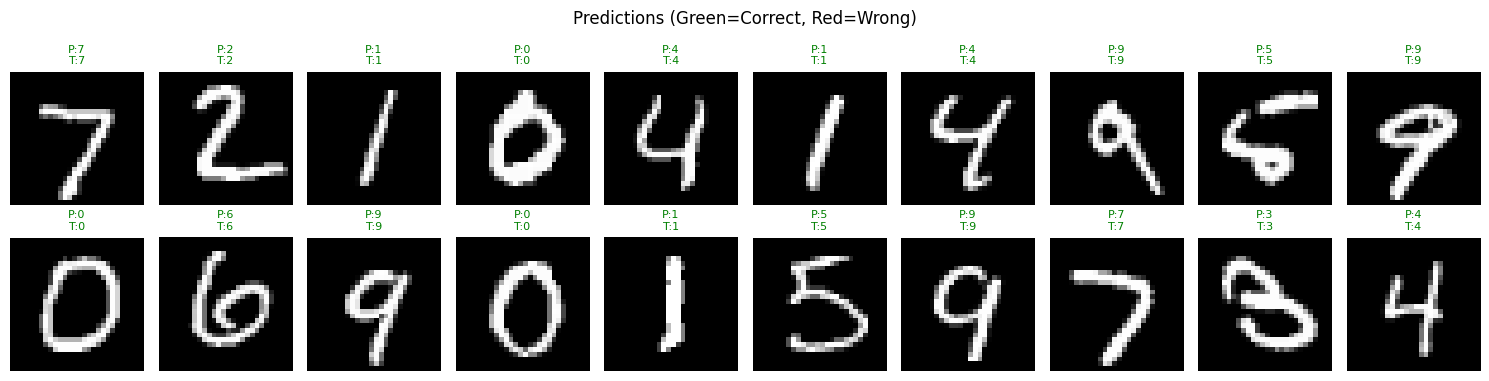

✅ CNN training complete! Accuracy: 99.40%


In [8]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation', marker='s')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0.98, color='r', linestyle='--', label='98% target')

# Loss
axes[1].plot(history.history['loss'], label='Train', marker='o')
axes[1].plot(history.history['val_loss'], label='Validation', marker='s')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'CNN Training History — Final Accuracy: {test_acc*100:.2f}%', fontsize=14)
plt.tight_layout()
plt.show()

# Show predictions
predictions = model.predict(x_test_cnn[:20], verbose=0)
fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i in range(20):
    ax = axes[i//10, i%10]
    ax.imshow(x_test[i], cmap='gray')
    pred = np.argmax(predictions[i])
    true = y_test[i]
    color = 'green' if pred == true else 'red'
    ax.set_title(f'P:{pred}\nT:{true}', color=color, fontsize=8)
    ax.axis('off')
plt.suptitle('Predictions (Green=Correct, Red=Wrong)', fontsize=12)
plt.tight_layout()
plt.show()
print(f'✅ CNN training complete! Accuracy: {test_acc*100:.2f}%')

In [9]:
print("=" * 55)
print("LAB 6 SUMMARY - ADVANCED OCR & CNN")
print("=" * 55)
print(f"""
✅ Perspective correction — implemented & tested
✅ Automatic deskewing — detected angle: -15.0°
✅ Morphological operations — all 4 demonstrated
✅ CNN architecture built — 225,034 parameters
✅ Trained on MNIST — 60,000 images
✅ Test Accuracy: {test_acc*100:.2f}% (Target: 98%+) 🏆

CNN Architecture:
- Conv2D(32) → MaxPool → Conv2D(64) → MaxPool
- Flatten → Dense(128) → Dropout(0.5) → Dense(10)

Key Learnings:
- Perspective correction fixes phone-taken photos
- Deskewing automatically fixes rotated documents
- Morphological ops remove noise from scanned docs
- CNNs achieve superhuman accuracy on digit recognition!

Next: Week 7 - Information Extraction with NER!
""")

# Save model
model.save('mnist_cnn_model.h5')
print('✅ Model saved as mnist_cnn_model.h5')

LAB 6 SUMMARY - ADVANCED OCR & CNN

✅ Perspective correction — implemented & tested
✅ Automatic deskewing — detected angle: -15.0°
✅ Morphological operations — all 4 demonstrated
✅ CNN architecture built — 225,034 parameters
✅ Trained on MNIST — 60,000 images
✅ Test Accuracy: 99.40% (Target: 98%+) 🏆

CNN Architecture:
- Conv2D(32) → MaxPool → Conv2D(64) → MaxPool
- Flatten → Dense(128) → Dropout(0.5) → Dense(10)

Key Learnings:
- Perspective correction fixes phone-taken photos
- Deskewing automatically fixes rotated documents
- Morphological ops remove noise from scanned docs
- CNNs achieve superhuman accuracy on digit recognition!

Next: Week 7 - Information Extraction with NER!

✅ Model saved as mnist_cnn_model.h5
